## Going to elucidate the little knowledge I have on multiple linear regression..

In [5]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [28]:
data = pd.read_csv("Student_Performance.csv")
mapping = {'Yes':1, 'No':0}
data['Extracurricular Activities'] = data['Extracurricular Activities'].map(mapping).astype(int)
x_train = np.array(data.iloc[:100 ,:5])
y_train = np.array(data.iloc[:100, 5])

In [7]:
b_init = 50.0
w_init = np.array([ 1 for i in range(5)])

In [8]:
def predict(x, w, b):

    p = np.dot(w, x) + b
    return p

In [9]:
x_vec = x_train[0, :]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (5,), x_vec value: [ 7 99  1  9  1]
f_wb shape (), prediction: 167.0


In [10]:
def compute_cost(x, y, w, b):
    cost = 0.0
    m = x.shape[0]
    for i in range(m):
        f_wb_i = np.dot(w, x[i]) + b
        cost = cost + (f_wb_i - y[i])**2
    cost = np.mean(cost)/2
    return cost

In [11]:
cost = compute_cost(x_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 320410.0


In [12]:
def compute_gradient(x, y, w, b):
    m,n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):
        err = (np.dot(x[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] += err*x[i,j]
        dj_db += err
    dj_dw = dj_dw/m
    dj_db = np.mean(dj_db)

    return dj_db, dj_dw

In [13]:
#Compute and display gradient 
tmp_dj_db, tmp_dj_dw = compute_gradient(x_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: 7984.0
dj_dw at initial w,b: 
 [ 411.5  5642.16   46.73  517.93  312.87]


Gradient Descent With Multiple Variables|

In [14]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, iter):
    J_history = []
    w_1_hist = []
    w = copy.deepcopy(w_in)
    b = b_in

    print("Iteration Cost        w0        w1        w2        w3        w4       b     "
          "dj_dw0  dj_dw1    dj_dw2    dj_dw3    dj_dw4    dj_db")

    print("-" * 130)
    
    for i in range(iter):
        dj_db, dj_dw = gradient_function(x, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        if i<100000:
            cost = cost_function(x, y, w, b)
            J_history.append(cost)

        if i% math.ceil(iter / 10) == 0:
            print(f"{i:9d} {cost:10.5e} "
              f"{w[0]:8.1e} {w[1]:8.1e} {w[2]:8.1e} {w[3]:8.1e} {w[4]:8.1e} "
              f"{b:8.1e} "
              f"{dj_dw[0]:8.1e} {dj_dw[1]:8.1e} "
              f"{dj_dw[2]:8.1e} {dj_dw[3]:8.1e} "
              f"{dj_dw[4]:8.1e} {dj_db:8.1e} "
            )
        w_1_hist.append(w[1])

    return w, b, J_history,w_1_hist
    

In [15]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# some gradient descent settings
iterations = 1000
alpha = 2.0e-4
# run gradient descent 
w_final, b_final, J_hist, w_1_hist = gradient_descent(x_train, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = x_train.shape
for i in range(m):
    print(f"prediction: {np.dot(x_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration Cost        w0        w1        w2        w3        w4       b     dj_dw0  dj_dw1    dj_dw2    dj_dw3    dj_dw4    dj_db
----------------------------------------------------------------------------------------------------------------------------------
        0 5.42490e+03  6.6e-02  8.7e-01  6.5e-03  7.4e-02  4.5e-02  1.1e+00 -3.3e+02 -4.3e+03 -3.2e+01 -3.7e+02 -2.2e+02 -5.7e+03 
      100 3.22615e+03  3.4e-01  8.1e-01 -1.1e-02 -4.7e-02  4.9e-03 -8.9e-01 -1.3e+01 -8.2e-01  8.0e-01  5.2e+00  1.5e+00  9.3e+01 
      200 2.69875e+03  6.0e-01  8.3e-01 -2.6e-02 -1.4e-01 -2.1e-02 -2.7e+00 -1.2e+01 -7.2e-01  7.1e-01  4.4e+00  1.1e+00  8.5e+01 
      300 2.27702e+03  8.2e-01  8.4e-01 -3.9e-02 -2.2e-01 -3.8e-02 -4.3e+00 -1.1e+01 -6.3e-01  6.2e-01  3.6e+00  6.9e-01  7.8e+01 
      400 1.93832e+03  1.0e+00  8.5e-01 -5.1e-02 -2.9e-01 -4.9e-02 -5.8e+00 -9.5e+00 -5.6e-01  5.5e-01  3.0e+00  3.9e-01  7.2e+01 
      500 1.66501e+03  1.2e+00  8.6e-01 -6.1e-02 -3.4e-01 -5.4e-02 -7.2e+00 -8.5e+0

In [16]:
p = []
for i in range(m):
    p.append(np.dot(x_train[i], w_final) + b_final)

np.sqrt(np.mean(( p - y_train ) ** 2))

np.float64(4.222805211260331)

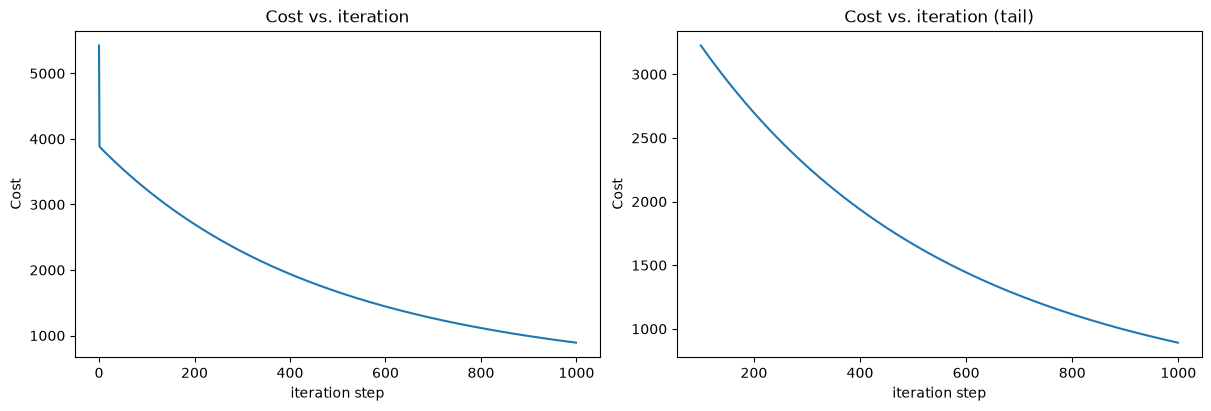

In [17]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

Some graph intuition

In [18]:
x_features = ['Hours Studied',"Previous Scores","Extracurricular Activities","Sleep_Hours","Sample Question Papers Practiced","Performance Index"]

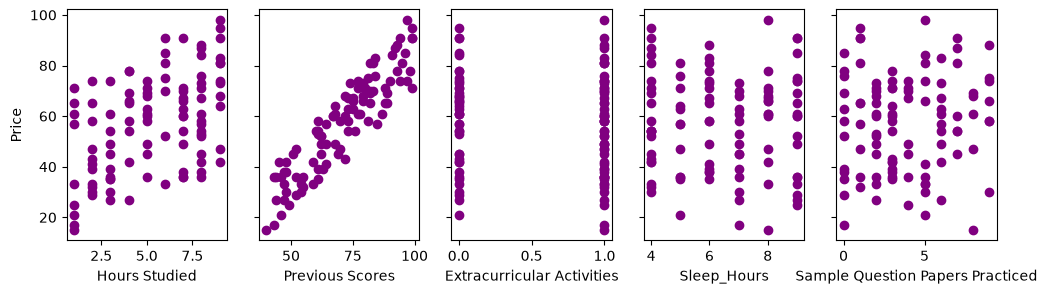

In [19]:
fig, ax = plt.subplots(1, 5, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_train[:, i], y_train,c='purple')
    ax[i].set_xlabel(x_features[i])
ax[0].set_ylabel("Price")
plt.show()

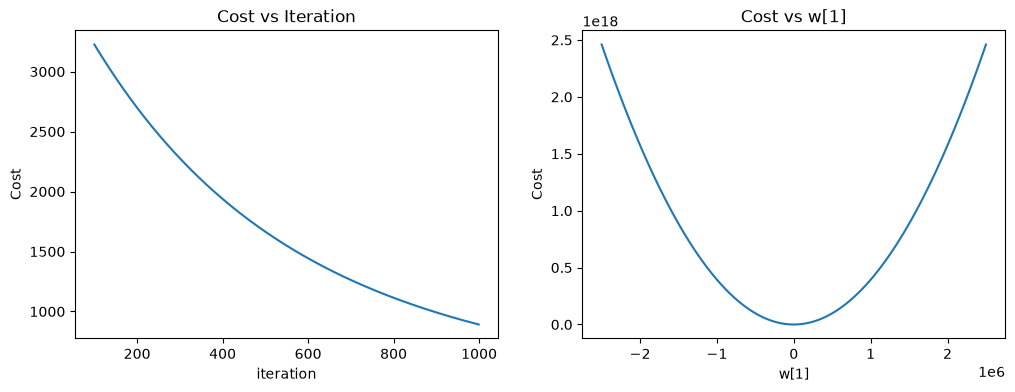

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])

w_range = np.linspace(-2500000, 2500000,100)

costs = []
for w in w_range:
    w_test = np.zeros(5)
    w_test[0] = w
    w_test[1] = w
    w_test[2] = w
    w_test[3] = w
    w_test[4] = w
    cost = compute_cost(x_train, y_train, w_test, -12.81)
    costs.append(cost)
    
ax2.plot(w_range, costs)
ax1.set_title('Cost vs Iteration')
ax1.set_xlabel('iteration')
ax1.set_ylabel('Cost')
ax2.set_title('Cost vs w[1]')
ax2.set_xlabel('w[1]')
ax2.set_ylabel('Cost')
ax2.plot(w_1_hist, J_hist)

## Feature Scaling implementation

In [21]:
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu)/sigma

    return (X_norm, mu, sigma)

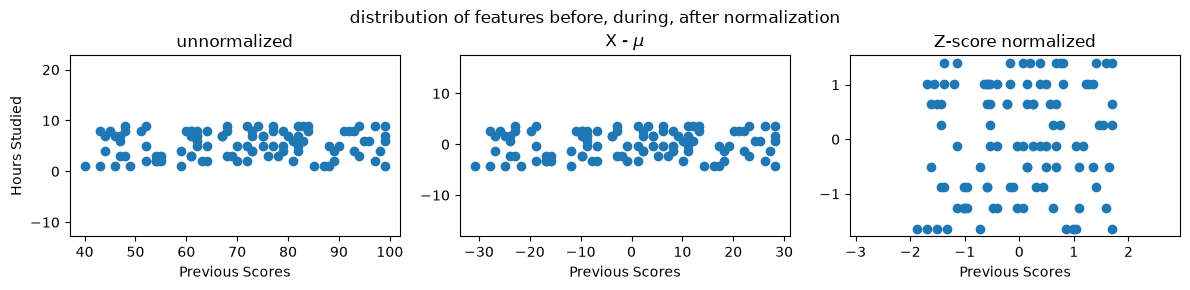

In [30]:
mu = np.mean(x_train, axis=0)
sigma = np.std(x_train, axis=0)
x_mean = (x_train - mu)
x_norm = (x_train - mu)/sigma

fig,ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].scatter(x_train[:,1], x_train[:,0])
ax[0].set_xlabel(x_features[1]); ax[0].set_ylabel(x_features[0]);
ax[0].set_title("unnormalized")
ax[0].axis('equal')

ax[1].scatter(x_mean[:,1], x_mean[:,0])
ax[1].set_xlabel(x_features[1]); ax[0].set_ylabel(x_features[0]);
ax[1].set_title(r"X - $\mu$")
ax[1].axis('equal')

ax[2].scatter(x_norm[:,1], x_norm[:,0])
ax[2].set_xlabel(x_features[1]); ax[0].set_ylabel(x_features[0]);
ax[2].set_title(r"Z-score normalized")
ax[2].axis('equal')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("distribution of features before, during, after normalization")
plt.show()